In [1]:
VIRUS_DATA = {
    "scenario_1": {
        "nom": "Enfants (5-10 ans)",
        "age_min": 5,
        "age_max": 10,
        "taux_infection": 0.03,  # 3%
        "niveau_risque": "FAIBLE",
        "action": "Surveillance légère",
        "couleur": "green"
    },
    "scenario_2": {
        "nom": "Adolescents (12-20 ans)",
        "age_min": 12,
        "age_max": 20,
        "taux_infection": 0.05,  # 5%
        "niveau_risque": "MODÉRÉ",
        "action": "Prévention renforcée",
        "couleur": "orange"
    },
    "scenario_3": {
        "nom": "Adultes (25-50 ans)",
        "age_min": 25,
        "age_max": 50,
        "taux_infection": 0.15,  # 15%
        "niveau_risque": "ÉLEVÉ",
        "action": "Vaccination prioritaire",
        "couleur": "red"
    }
}

print("Bibliothèque de données chargée")
print(f"Nombre de scénarios définis: {len(VIRUS_DATA)}")

Bibliothèque de données chargée
Nombre de scénarios définis: 3


In [2]:
def rechercher_scenario(age):
    """
    Recherche le scénario correspondant à l'âge donné.
    """
    for scenario_id, scenario in VIRUS_DATA.items():
        if scenario["age_min"] <= age <= scenario["age_max"]:
            return scenario
    return None

def calculer_personnes_atteintes(age, population_totale):
    """
    Calcule le nombre de personnes atteintes dans une population.
    """
    scenario = rechercher_scenario(age)
    
    if scenario:
        nombre_atteints = int(population_totale * scenario["taux_infection"])
        return nombre_atteints, scenario
    else:
        return 0, None

print("Fonctions de recherche créées")

Fonctions de recherche créées


In [3]:
print("=" * 60)
print("         TEST DES 3 SCÉNARIOS DE BASE")
print("=" * 60)

# Définir les cas de test pour chaque scénario
tests = [
    {"age": 7, "population": 500, "scenario_attendu": 1},
    {"age": 15, "population": 800, "scenario_attendu": 2},
    {"age": 35, "population": 1200, "scenario_attendu": 3}
]

for i, test in enumerate(tests, 1):
    print(f"SCÉNARIO {i}:")
    print("-" * 40)
    
    nombre_atteints, scenario = calculer_personnes_atteintes(test["age"], test["population"])
    
    if scenario:
        print(f"Tranche d'âge: {scenario['nom']}")
        print(f"Population testée: {test['population']} personnes")
        print(f"Taux d'infection: {scenario['taux_infection']*100}%")
        print(f"Personnes atteintes: {nombre_atteints}")
        print(f"Niveau de risque: {scenario['niveau_risque']}")
        print(f"Action recommandée: {scenario['action']}")
        
        pourcentage = (nombre_atteints / test["population"]) * 100
        print(f"Pourcentage réel: {pourcentage:.2f}%")

         TEST DES 3 SCÉNARIOS DE BASE
SCÉNARIO 1:
----------------------------------------
Tranche d'âge: Enfants (5-10 ans)
Population testée: 500 personnes
Taux d'infection: 3.0%
Personnes atteintes: 15
Niveau de risque: FAIBLE
Action recommandée: Surveillance légère
Pourcentage réel: 3.00%
SCÉNARIO 2:
----------------------------------------
Tranche d'âge: Adolescents (12-20 ans)
Population testée: 800 personnes
Taux d'infection: 5.0%
Personnes atteintes: 40
Niveau de risque: MODÉRÉ
Action recommandée: Prévention renforcée
Pourcentage réel: 5.00%
SCÉNARIO 3:
----------------------------------------
Tranche d'âge: Adultes (25-50 ans)
Population testée: 1200 personnes
Taux d'infection: 15.0%
Personnes atteintes: 180
Niveau de risque: ÉLEVÉ
Action recommandée: Vaccination prioritaire
Pourcentage réel: 15.00%


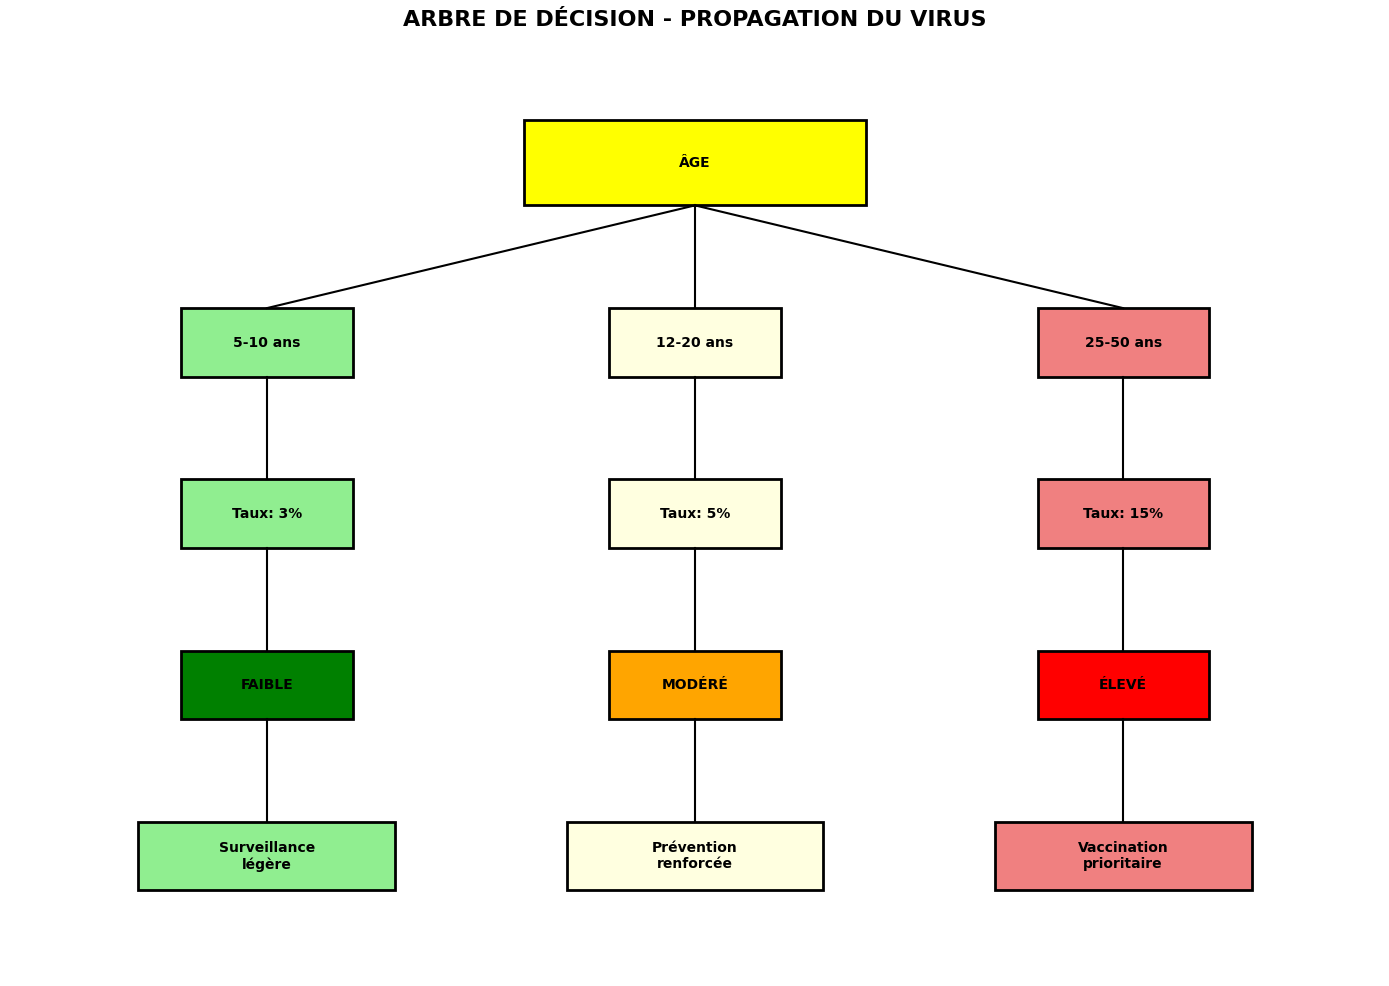

Arbre de décision généré et sauvegardé : arbre_decision_virus.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 10))

def draw_box(ax, x, y, width, height, text, color='lightblue'):
    rect = patches.Rectangle((x, y), width, height, linewidth=2, 
                            edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold')

draw_box(ax, 5, 8, 4, 1, "ÂGE", 'yellow')

draw_box(ax, 1, 6, 2, 0.8, "5-10 ans", 'lightgreen')
draw_box(ax, 6, 6, 2, 0.8, "12-20 ans", 'lightyellow')
draw_box(ax, 11, 6, 2, 0.8, "25-50 ans", 'lightcoral')

draw_box(ax, 1, 4, 2, 0.8, "Taux: 3%", 'lightgreen')
draw_box(ax, 6, 4, 2, 0.8, "Taux: 5%", 'lightyellow')
draw_box(ax, 11, 4, 2, 0.8, "Taux: 15%", 'lightcoral')

draw_box(ax, 1, 2, 2, 0.8, "FAIBLE", 'green')
draw_box(ax, 6, 2, 2, 0.8, "MODÉRÉ", 'orange')
draw_box(ax, 11, 2, 2, 0.8, "ÉLEVÉ", 'red')

draw_box(ax, 0.5, 0, 3, 0.8, "Surveillance\nlégère", 'lightgreen')
draw_box(ax, 5.5, 0, 3, 0.8, "Prévention\nrenforcée", 'lightyellow')
draw_box(ax, 10.5, 0, 3, 0.8, "Vaccination\nprioritaire", 'lightcoral')

lines = [
    [(7, 8), (2, 6.8)],
    [(7, 8), (7, 6.8)],
    [(7, 8), (12, 6.8)],
    [(2, 6), (2, 4.8)],
    [(7, 6), (7, 4.8)],
    [(12, 6), (12, 4.8)],
    [(2, 4), (2, 2.8)],
    [(7, 4), (7, 2.8)],
    [(12, 4), (12, 2.8)],
    [(2, 2), (2, 0.8)],
    [(7, 2), (7, 0.8)],
    [(12, 2), (12, 0.8)]
]

for line in lines:
    ax.plot([line[0][0], line[1][0]], [line[0][1], line[1][1]], 
            'k-', linewidth=1.5)

ax.set_xlim(-1, 15)
ax.set_ylim(-1, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("ARBRE DE DÉCISION - PROPAGATION DU VIRUS", 
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig("arbre_decision_virus.png", dpi=150, bbox_inches='tight')
plt.show()

print("Arbre de décision généré et sauvegardé : arbre_decision_virus.png")

In [5]:
def analyser_population_complete(donnees_population):
    """Analyse complète avec statistiques"""
    
    print("=" * 60)
    print("     ANALYSE COMPLÈTE DE LA POPULATION")
    print("=" * 60)
    
    resultats = []
    total_pop = 0
    total_atteints = 0
    
    for age_representatif, nombre in donnees_population.items():
        atteints, scenario = calculer_personnes_atteintes(age_representatif, nombre)
        
        if scenario:
            total_pop += nombre
            total_atteints += atteints
            
            resultats.append({
                'scenario': scenario['nom'],
                'population': nombre,
                'atteints': atteints,
                'taux': scenario['taux_infection'],
                'risque': scenario['niveau_risque'],
                'action': scenario['action'],
                'couleur': scenario['couleur']
            })
    
    # Affichage des résultats
    print("DÉTAILS PAR TRANCHE D'ÂGE:\n")
    
    for r in resultats:
        print(f"{r['scenario']}")
        print(f"   Population: {r['population']:,} personnes")
        print(f"   Atteints estimés: {r['atteints']:,} personnes")
        print(f"   Taux d'infection: {r['taux']*100:.1f}%")
        print(f"   Niveau de risque: {r['risque']}")
        print(f"   Action: {r['action']}")
        print("-" * 40)
    
    # Statistiques globales
    print("STATISTIQUES GLOBALES:")
    print(f"   Population totale: {total_pop:,} personnes")
    print(f"   Total atteints estimés: {total_atteints:,} personnes")
    print(f"   Taux global: {(total_atteints/total_pop)*100:.2f}%")
    
    return resultats

# Données de test : population d'une ville
population_ville = {
    7: 2500,    # Enfants
    15: 3200,   # Adolescents  
    35: 5800    # Adultes
}

resultats = analyser_population_complete(population_ville)

     ANALYSE COMPLÈTE DE LA POPULATION
DÉTAILS PAR TRANCHE D'ÂGE:

Enfants (5-10 ans)
   Population: 2,500 personnes
   Atteints estimés: 75 personnes
   Taux d'infection: 3.0%
   Niveau de risque: FAIBLE
   Action: Surveillance légère
----------------------------------------
Adolescents (12-20 ans)
   Population: 3,200 personnes
   Atteints estimés: 160 personnes
   Taux d'infection: 5.0%
   Niveau de risque: MODÉRÉ
   Action: Prévention renforcée
----------------------------------------
Adultes (25-50 ans)
   Population: 5,800 personnes
   Atteints estimés: 870 personnes
   Taux d'infection: 15.0%
   Niveau de risque: ÉLEVÉ
   Action: Vaccination prioritaire
----------------------------------------
STATISTIQUES GLOBALES:
   Population totale: 11,500 personnes
   Total atteints estimés: 1,105 personnes
   Taux global: 9.61%


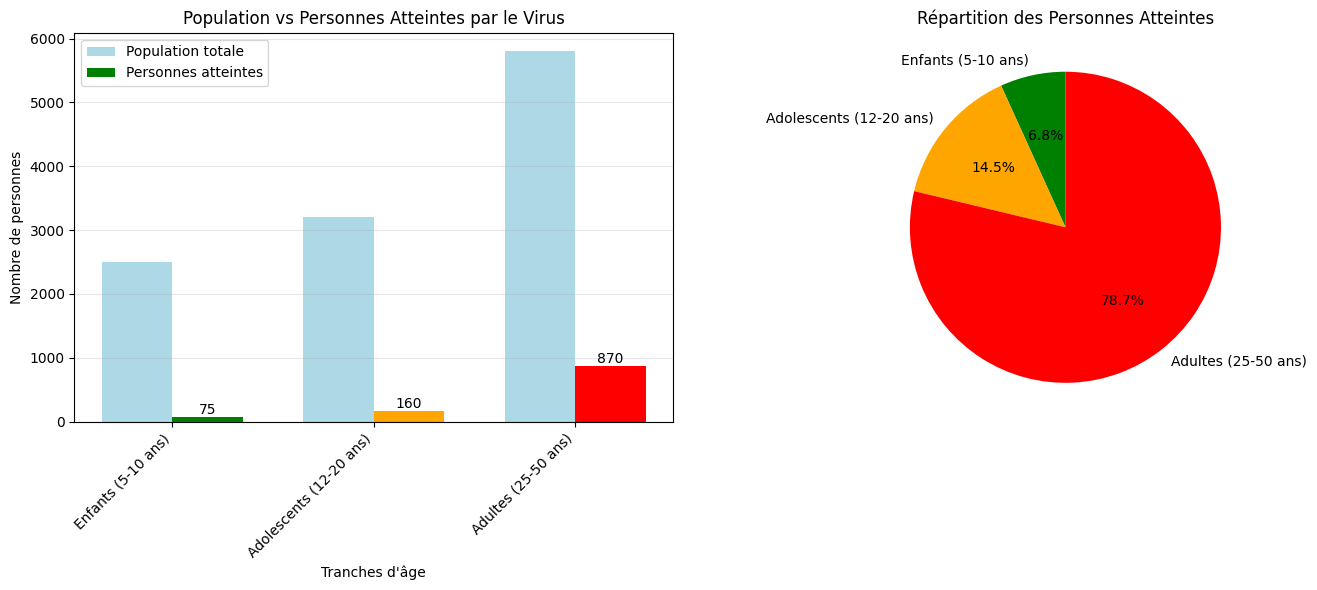

Graphiques sauvegardés : analyse_virus.png


In [6]:
import matplotlib.pyplot as plt

categories = [r['scenario'] for r in resultats]
populations = [r['population'] for r in resultats]
atteints = [r['atteints'] for r in resultats]
couleurs = [r['couleur'] for r in resultats]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = range(len(categories))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], populations, width, 
                label='Population totale', color='lightblue')
bars2 = ax1.bar([i + width/2 for i in x], atteints, width, 
                label='Personnes atteintes', color=couleurs)

ax1.set_xlabel('Tranches d\'âge')
ax1.set_ylabel('Nombre de personnes')
ax1.set_title('Population vs Personnes Atteintes par le Virus')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

# Graphique 2 : Camembert des proportions d'atteints
ax2.pie(atteints, labels=categories, colors=couleurs, 
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Répartition des Personnes Atteintes')

plt.tight_layout()
plt.savefig("analyse_virus.png", dpi=150, bbox_inches='tight')
plt.show()

print("Graphiques sauvegardés : analyse_virus.png")

In [ ]:
print("=" * 60)
print("     SIMULATION PERSONNALISÉE")
print("=" * 60)
print("\nTestez avec vos propres valeurs!")
print("(Laissez vide et appuyez sur Entrée pour terminer)\n")

while True:
    try:
        age_str = input("Entrez l'âge de la personne: ")
        if not age_str:
            print("Simulation terminée.")
            break
            
        age = int(age_str)
        pop_str = input("Entrez la taille de la population: ")
        population = int(pop_str)
        
        atteints, scenario = calculer_personnes_atteintes(age, population)
        
        print("\n" + "=" * 40)
        if scenario:
            print(f"RÉSULTATS POUR {age} ANS:")
            print(f"   Catégorie: {scenario['nom']}")
            print(f"   Population: {population:,} personnes")
            print(f"   Estimation atteints: {atteints:,} personnes")
            print(f"   Taux: {scenario['taux_infection']*100}%")
            print(f"   Risque: {scenario['niveau_risque']}")
            print(f"   Action: {scenario['action']}")
        else:
            print(f"L'âge {age} n'est pas dans les scénarios définis")
            print("   Tranches couvertes: 5-10, 12-20, 25-50 ans")
        print("=" * 40 + "\n")
        
    except ValueError:
        print("Veuillez entrer des nombres valides")
    except KeyboardInterrupt:
        print("\nSimulation interrompue.")
        break

     SIMULATION PERSONNALISÉE

Testez avec vos propres valeurs!
(Laissez vide et appuyez sur Entrée pour terminer)

